In [27]:
import open_clip
print("Available Models:", open_clip.list_pretrained())

Available Models: [('RN50', 'openai'), ('RN50', 'yfcc15m'), ('RN50', 'cc12m'), ('RN101', 'openai'), ('RN101', 'yfcc15m'), ('RN50x4', 'openai'), ('RN50x16', 'openai'), ('RN50x64', 'openai'), ('ViT-B-32', 'openai'), ('ViT-B-32', 'laion400m_e31'), ('ViT-B-32', 'laion400m_e32'), ('ViT-B-32', 'laion2b_e16'), ('ViT-B-32', 'laion2b_s34b_b79k'), ('ViT-B-32', 'datacomp_xl_s13b_b90k'), ('ViT-B-32', 'datacomp_m_s128m_b4k'), ('ViT-B-32', 'commonpool_m_clip_s128m_b4k'), ('ViT-B-32', 'commonpool_m_laion_s128m_b4k'), ('ViT-B-32', 'commonpool_m_image_s128m_b4k'), ('ViT-B-32', 'commonpool_m_text_s128m_b4k'), ('ViT-B-32', 'commonpool_m_basic_s128m_b4k'), ('ViT-B-32', 'commonpool_m_s128m_b4k'), ('ViT-B-32', 'datacomp_s_s13m_b4k'), ('ViT-B-32', 'commonpool_s_clip_s13m_b4k'), ('ViT-B-32', 'commonpool_s_laion_s13m_b4k'), ('ViT-B-32', 'commonpool_s_image_s13m_b4k'), ('ViT-B-32', 'commonpool_s_text_s13m_b4k'), ('ViT-B-32', 'commonpool_s_basic_s13m_b4k'), ('ViT-B-32', 'commonpool_s_s13m_b4k'), ('ViT-B-32', 'me

In [28]:
# Load model
model, _, preprocess = open_clip.create_model_and_transforms('ViT-B-32-quickgelu', pretrained='laion400m_e32')
# ViT-B-32: use a Vision Transformer (ViT) base-size (B) model as the image encoder with an image patch size of 32
# Pretrained on the LAION-400M dataset, epoch = 32 (e32)

print("Preprocess:", preprocess)
# Preprocessing mainly involves resizing to 224px square images and normalizing the image data

Preprocess: Compose(
    Resize(size=224, interpolation=bicubic, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    MaybeConvertMode()
    MaybeToTensor()
    Normalize(mean=(0.48145466, 0.4578275, 0.40821073), std=(0.26862954, 0.26130258, 0.27577711))
)


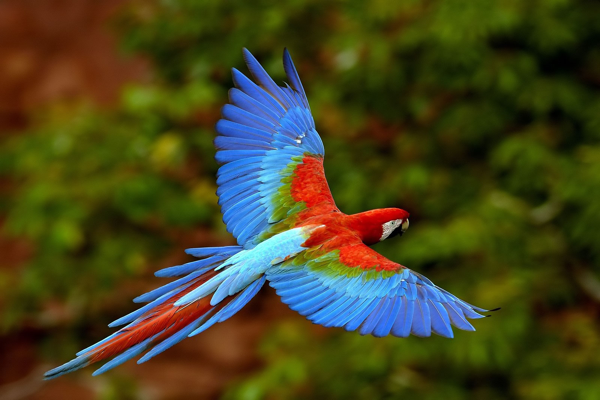

In [29]:
# Load and resize the image
from PIL import Image

input_image = Image.open("img/parrot.jpg").resize((600, 400))
input_image

Image.shape: torch.Size([1, 3, 224, 224]) Image_features.shape: torch.Size([1, 512])


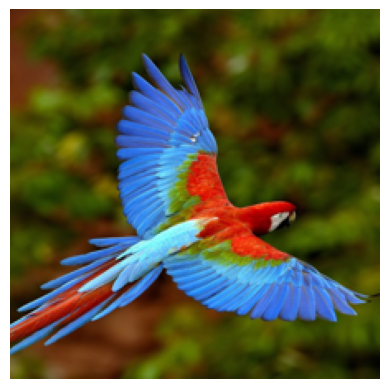

In [30]:
# Preprocess the image, turn it into a CLIP embedding -> image_features
import torch
import matplotlib.pyplot as plt

image = preprocess(input_image).unsqueeze(0)

with torch.no_grad(), torch.amp.autocast("cuda"):   # For saving memory & speeding up training
    image_features = model.encode_image(image)      # Turn into a CLIP embedding
    
print('Image.shape:', image.shape, 'Image_features.shape:', image_features.shape)

# Remove the batch dimension and clone the tensor
img = image.squeeze(0).clone().detach()

# Define standard OpenAI CLIP mean and std deviation
mean = torch.tensor([0.48145466, 0.4578275, 0.40821073]).view(3, 1, 1)
std = torch.tensor([0.26862954, 0.26130258, 0.27577711]).view(3, 1, 1)

# Reverse the normalization: (image * std) + mean
img = img * std + mean

# Clamp values to ensure they stay strictly between [0, 1]
img = torch.clamp(img, 0, 1)

# Permute dimensions from [C, H, W] to [H, W, C] for Matplotlib
img_np = img.permute(1, 2, 0).cpu().numpy()

# Plot the restored image
plt.imshow(img_np)
plt.axis('off')
plt.show()

In [35]:
# Generate text features
text = open_clip.tokenize(["a cat", "a bird", "a dog"])

with torch.no_grad(), torch.amp.autocast("cuda"):   # For saving memory & speeding up training
    text_features = model.encode_text(text)
    
print('Tokenized text shape:', text.shape)
print('Text_features.shape:', text_features.shape)

Tokenized text shape: torch.Size([3, 77])
Text_features.shape: torch.Size([3, 512])


In [37]:
# Computing similarities
"""
    calculate the matching probability scores between a set of image features and text features
"""
def probability_scores(image_features, text_features):
    # feature normalization - scale every vector to a length of 1, ensuring only the angle of the vectors matters for comparison rather than their raw magnitude
    image_features /= image_features.norm(dim=-1, keepdim=True)         # (1, 512)
    text_features /= text_features.norm(dim=-1, keepdim=True)           # (3, 512)
    
    # Cosine similarity matrix - a matrix multiplication between the normalized image features and the transposed normalized text features
    text_probs = (image_features @ text_features.T).softmax(dim=-1)     # (1, 3)

    return text_probs

torch.set_printoptions(precision=3)
# the following 2 operations for Cosine similarity calculation are identical
print("Label probs:", probability_scores(image_features, text_features))
print("Label probs:", torch.nn.functional.cosine_similarity(image_features, text_features).softmax(dim=-1))

Label probs: tensor([[0.314, 0.366, 0.321]])
Label probs: tensor([0.314, 0.366, 0.321])
